## Part 1 : Medical Appointment No-Shows: Exploratory Data Analysis (EDA)

    In Part 1 of this project we walk through the process of examining and understanding the characteristics or attributes (features) of a dataset. The datasets used in this project is "KaggleV2-May-2016.csv", which contains informations about medical appointments in Brazil. The main question we are trying to answer here is what factors are important for us to know in order to predict if a patient will show up for their scheduled appointment?

**Dataset:** Brazilian Medical Appointment No-shows (kaggle)

**Total Records:** 110,282 appointments

**No-show Rate:** 20%

### Table of Contents

     1. Project Overview
     
     2. Environment Setup

     3. Data Preparation for Plotting

     4. Exploratory Data Analysis
     
     5. Statistical Methods
    
     6. Key Findings

     7. Visualizations

     8. Conclusions % Recommendations

     9. References

### Project Overview
#### Objective

Identify and quantify the key factors influencing medical appointment no-show rates in a Brazilian healthcare system. Move beyond simple statistical significance to assess practical relevance using effect size metrics (Cramer's V). Dataset Characteristics The dataset comprises 110,282 medical appointments with the following features:

1- **PatientId:** indicates the id that identifies each patient.

2- **AppointmentID:** indicates the id that identifies each appointment.

3- **Gender indicates:** the patient's gender (Female 'F' or Male 'M').

4- **ScheduledDay:** tells us on what day the patient set up their appointment.

5- A**ppointmentDay:** when will the appointment take place.

6- **Age:** tells how old is the patient.

7- **Neighborhood:** indicates the location of the hospital.

8- **Scholarship:** indicates whether or not the patient is enrolled in Brasilian welfare program Bolsa Família.

9- **Hipertension:** the patient has hipertension or not.

10- **Diabetes the:** patient is with diabetes or not.

11- **Alcoholism:** the patient consumes alcohol or not.

12- **Handcap:** the patient is handicapped or not and the number of disabillities the have.

13- **SMS_received:** the patient received a SMS or not.

14- **No-show:** Be careful about the encoding of the last column: it says ‘No’ if the patient showed up to their appointment, and ‘Yes’ if they did not show up.

#### Key Questions:

1. Which features have the strongest association with no-shows?
2. Are these associations statistically significant
and practically meaningful?
3. What interaction effects exist between features?
4. What actionable recommendations can improve attendance?


### 1. Environment Setup

In [1]:
# IMPORTING DEPENDENCIES

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Enabling inline plotting in the notebook 
%matplotlib inline

# Core libraries for data analysis
import numpy as np, pandas as pd, webbrowser, pickle, zipfile, os

# Scipy library
from scipy import stats

# Set up parameters in pandas
pd.set_option('display.notebook_repr_html', True, 'display.max_rows', 1000, 'display.max_columns', 100,
              'display.float_format', lambda x:"{:.2f}".format(x))

# Seaborn and Matplotlib for plotting
import matplotlib.pyplot as plt, seaborn as sns



# Set up parameters in Matplotlib
params = {'axes.titlesize':10.2, 'axes.spines.top':False, 'axes.spines.right':False,
          'xtick.labelsize':8.2, 'ytick.labelsize':8.2, 'figure.figsize':[9.8, 8], 'font.size':8}

plt.rcParams.update(params)

### **2. Data Loading & Initial Inspection**
    Downloading dataset from kaggle website require API from personal account. There we have create an account if we don not have one!

In [2]:
# 2.1 Create a .kaggle hidden file and move creadential kaggle json file to the hidden file by sitting permition
! mkdir -p ~/.kaggle && cp /Users/apple/Downloads/kaggle.json /Users/apple/.kaggle/ && chmod 600 /Users/apple/.kaggle/kaggle.json

# Downloads and unzip the dataset to your local machine
! kaggle datasets download -d joniarroba/noshowappointments

with zipfile.ZipFile('noshowappointments.zip', 'r') as z:
    z.extractall('../notebook/')

data = pd.read_csv('KaggleV2-May-2016.csv', parse_dates=['ScheduledDay', 'AppointmentDay'])
data.head()

Dataset URL: https://www.kaggle.com/datasets/joniarroba/noshowappointments
License(s): CC-BY-NC-SA-4.0
noshowappointments.zip: Skipping, found more recently modified local copy (use --force to force download)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,29872499824296.00,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,558997776694438.00,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4262962299951.00,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,867951213174.00,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8841186448183.00,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No


#### 2.2 Displaying datasets in HTML format:

    This enables us to visualize the data more effectively than in a Jupyter Notebook

In [3]:
# 2.3 Define a function that dispaly datasets on web browser
def html_data(data=data[:500]):
    """Display first 500 rows as HTML in browser"""
    # Define a temporary html file
    html = data.to_html()
    
    # Save the temporary file
    with open('data.html', 'w') as f:
        f.write(html)

    # Define the full path for file
    file_name = os.path.abspath('data.html')

    # Open webbrowser
    webbrowser.open(f'file://{file_name}')

# Display data on a web browser
html_data()

### 3. Descriptive Analysis:

    Descriptive statistics provide insight into the dataset's structure, helping to identify missing values, unusual observations, and data types.




#### 3.1 Info:
    This returns a summary of the dataset's characteristics, including its shape, which consists of the number of rows and columns. Additionally, it provides information about the column names, their respective data types, and any missing values within the dataset

In [4]:
# 3.1.a Quick overview to detect nulls and check data types.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110527 non-null  float64            
 1   AppointmentID   110527 non-null  int64              
 2   Gender          110527 non-null  object             
 3   ScheduledDay    110527 non-null  datetime64[ns, UTC]
 4   AppointmentDay  110527 non-null  datetime64[ns, UTC]
 5   Age             110527 non-null  int64              
 6   Neighbourhood   110527 non-null  object             
 7   Scholarship     110527 non-null  int64              
 8   Hipertension    110527 non-null  int64              
 9   Diabetes        110527 non-null  int64              
 10  Alcoholism      110527 non-null  int64              
 11  Handcap         110527 non-null  int64              
 12  SMS_received    110527 non-null  int64              
 13  No-show       

    Summary: 110,527 rows × 14 columns. All features have non-null values. ScheduledDay and AppointmentDay were string object but were processed as datetime objects on data loading.

#### 3.2 Satistical summary:

    The "describe()" is a useful function for generating descriptive statistics of a DataFrame or Series to helping us quickly understand its distribution and key properties.

In [5]:
# 3.2.a Summary statistics to find outliers and frequency counts
data.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
PatientId,110527.00,NaN,NaN,NaN,147496265710394.06,39217.84,4172614444192.00,31731838713978.00,94391720898175.00,999981631772427.00,256094920291739.09
AppointmentID,110527.00,NaN,NaN,NaN,5675305.12,5030230.00,5640285.50,5680573.00,5725523.50,5790484.00,71295.75
Gender,110527,2,F,71840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ScheduledDay,110527,NaN,NaN,NaN,2016-05-09 07:49:15.846273024+00:00,2015-11-10 07:13:56+00:00,2016-04-29 10:27:01+00:00,2016-05-10 12:13:17+00:00,2016-05-20 11:18:37+00:00,2016-06-08 20:07:23+00:00,NaN
AppointmentDay,110527,NaN,NaN,NaN,2016-05-19 00:57:50.008233472+00:00,2016-04-29 00:00:00+00:00,2016-05-09 00:00:00+00:00,2016-05-18 00:00:00+00:00,2016-05-31 00:00:00+00:00,2016-06-08 00:00:00+00:00,NaN
Age,110527.00,NaN,NaN,NaN,37.09,-1.00,18.00,37.00,55.00,115.00,23.11
Neighbourhood,110527,81,JARDIM CAMBURI,7717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Scholarship,110527.00,NaN,NaN,NaN,0.10,0.00,0.00,0.00,0.00,1.00,0.30
Hipertension,110527.00,NaN,NaN,NaN,0.20,0.00,0.00,0.00,0.00,1.00,0.40
Diabetes,110527.00,NaN,NaN,NaN,0.07,0.00,0.00,0.00,0.00,1.00,0.26


#### 3.2.b  Observations:

        . PatientId & AppointmentID do not seem to be useful for prediction.

        . Negative ages indicate data entry errors.

        . Rare Age=115 is plausible but uncommon.

        . Handcap has unusual values; needs binary encoding.

        . No-show is imbalanced (~20% no-shows).

### 4. Data Cleaning:
    Data cleaning includes preprocessing our dataset suitable for plotting the features for further exploration.
    

In [6]:
# 4.1 Create a data cleaning function for exploratory analysis
def data_cleaning(data):
    '''Returns features of the dataset suitable for
    exploratory analysis. '''
    
    # Make a copy of data to preserve the original
    df = data.copy()
    
    # Convert features' name into lower cases
    df.columns = df.columns.str.lower()
    
    # Remove ID columns
    cols_to_drop = [column for column in ['patientid', 'appointmentid'] if column in df.columns]
    df.drop(cols_to_drop, axis=1, inplace=True)
    
    # Convert Age into positive values
    if 'age' in df.columns:
        df['age'] = df['age'].abs()
    
    # Encode handcap
    if 'handcap' in df.columns:   # If condition used to present error
        df.rename(columns={'handcap':'handicap'}, inplace=True)
        # Convert 'handicap' feature into a binary
        df['handicap'] = np.where(df['handicap'] == 0, 0, 1)
    
    
    # Create Datetime Components
    # Remove rows where appointmentday are inferior than scheduledday
    df = df.loc[~(df['appointmentday'].dt.date < df['scheduledday'].dt.date)]
        
    # Remove hours components and compute the difference between appointment and schedledday
    df['waitingdays'] = (df['appointmentday'].dt.normalize() - df['scheduledday'].dt.normalize()).dt.days
    
    # Create appointmentday_weekday and appointmentday_hours components
    for column in ['scheduledday', 'appointmentday']:
         df[f"{column}_weekday"] = df[column].dt.weekday
         df['appointmentday_weekday'] = df['appointmentday'].dt.dayofweek
        
    
    # Drop Unnecessary Columns including scheduledday and appointmentday
    df.drop(['scheduledday', 'appointmentday'], axis=1, inplace=True)

    # Return data frame
    return df
    
# Display first 5 rows
df = data_cleaning(data)

df.head()

,gender,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handicap,sms_received,no-show,waitingdays,scheduledday_weekday,appointmentday_weekday
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0,4,4
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0,4,4
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,No,0,4,4
3,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0,4,4
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,No,0,4,4


### 5. Exploratory Data Analysis (EDA):

    EDA is the process of visually and statistically exploring data to uncover patterns, trends, and relationships between variables. It involves creating various plots and charts to gain insights into the data and identify potential areas for further investigation.

    We can divide the exploratory data analysis into two parts: Univariate and Bivariate Plots.

#### 5.1 Univariate Analysis:

    This section examines each feature individually to understand data quality, detect anomalies, and identify potential predictors of appointment attendance.

#### 5.1.a Column Partioning for Plots:
    Column partioning involve separating columns into lists of continuous and categorical just for plotting purpose.

In [7]:
# 5.1.b Define a function that separate features itno categories
def column_partitioning(df=df):
    '''Returns lists of continuous and categorical features'''
    cont_cols, cat_cols = [], []

    # Loop through columns
    for column in df.columns:
        # Set conditions for continuous features
        if len(df[column].unique()) > 90:
            cont_cols.append(column)
        else:
            cat_cols.append(column)
    
    # Return lists
    return cont_cols, cat_cols

# Store lists of features
cont_cols, cat_cols = column_partitioning()

#### 5.2 Function for plotting feature distributions

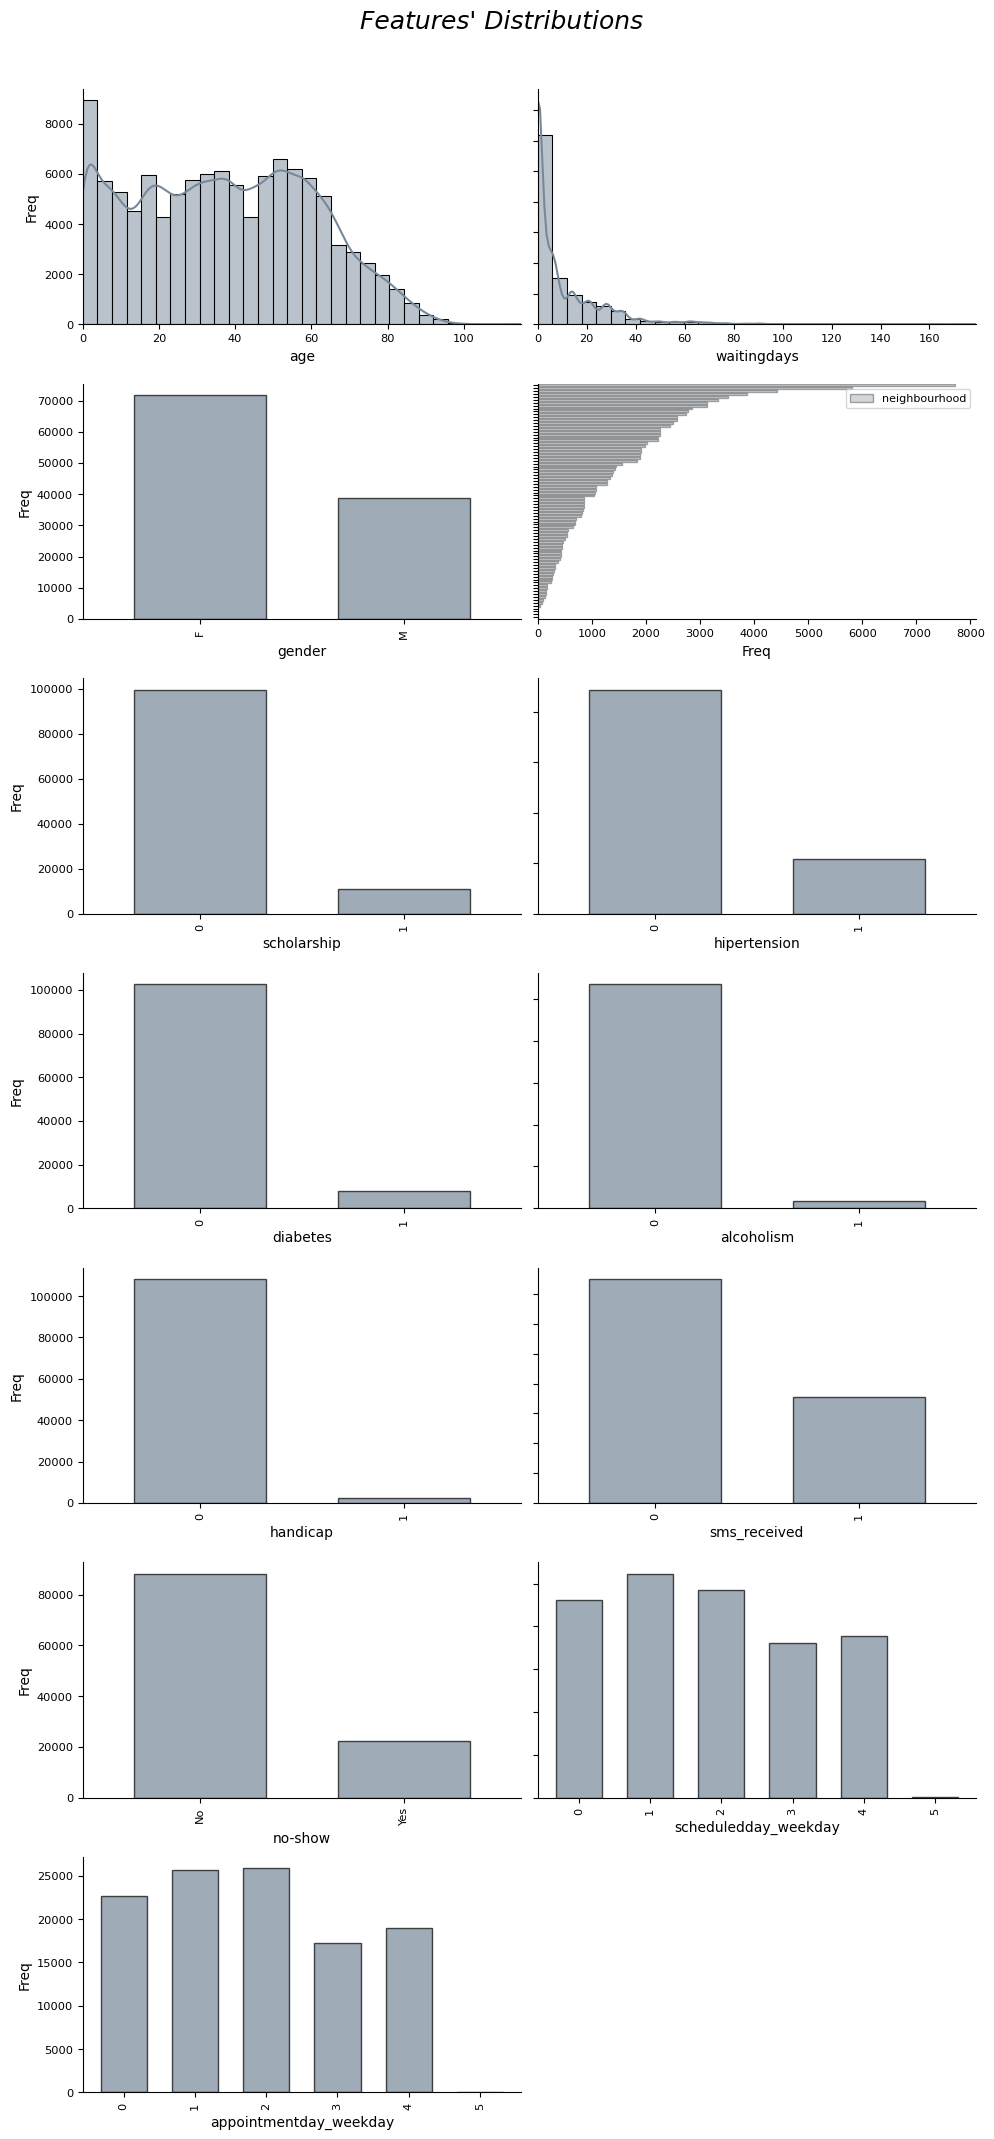

In [8]:
# 5.2.a Define a Univariate Plot
def univariate_plots(df, cont_cols, cat_cols):
    '''Returns a grid of continuous and categirical plots'''
    # Total of giving features
    total_cols = len(cont_cols) + len(cat_cols)
    
    # Number of rows to use in grid plot
    num_rows = int(np.ceil(total_cols / 2))

    # Number of columns to use in grid plot
    num_cols = min(total_cols, 2)
    
    # Initiate coun plot
    countplot = 1
    # Define figure for plot
    plt.figure(figsize=[10, 3 * num_rows])

    # Loop through continuous columns
    for column in cont_cols:
        # Set up grid plot
        plt.subplot(num_rows, num_cols, countplot)

        # Create a histogram plot for every continuous feature
        #df[column].plot(kind='hist', bins=30, alpha=.3, edgecolor='k', sharey=True)
        sns.histplot(x=df[column], bins=30, kde=True, color='lightslategray')

        # Adjust x, and y axis
        plt.xlim([0, df[column].max()])
        plt.xlabel(column, fontsize=10)
        plt.ylabel('Freq', fontsize=10)

        # Increment the plot
        countplot+=1

    # Loop through categorical columns
    for column in cat_cols:
        # Set up grid plot
        plt.subplot(num_rows, num_cols, countplot)
        
        if column == 'neighbourhood':  # We selcted bc it's a nominal category
            # Display bars by values' order
            df[column].value_counts().sort_values().plot(kind='barh', width=.65, color='lightslategray', alpha=.33, edgecolor='k', label=column)
            plt.legend()
            plt.xlabel('Freq', fontsize=10)
            plt.ylabel(column, fontsize=10)
            plt.yticks(fontsize=3)

        else:
            df[column].value_counts().sort_index().plot(kind='bar', width=.65, color='lightslategray',
                                                        alpha=.7, edgecolor='k', sharey=True)
            # Adjust x, and y axis label size
            plt.xlabel(column, fontsize=10)
            plt.ylabel('Freq', fontsize=10)

        countplot+=1
        
    plt.suptitle(" Features' Distributions", fontsize=18, y=1.015, style='italic')
    
    plt.tight_layout()

    # Show plot
    plt.show()

# Plot the features
univariate_plots(df, cont_cols, cat_cols)

#### 5.2.b Key Insights

**Age Distribution:**

- Most patients are adults and seniors, with relatively few children and very elderly patients. This suggests that age-related factors—such as chronic conditions or work constraints—may play a role in appointment adherence
- A small number of unrealistic ages and outliers appear, justifying cleaning and binning.

**Appointment Timing:**
- A large proportion of appointments are scheduled for the same day, producing a highly skewed waiting-time distribution.
- The clinic does not operate on Sundays, and appointments cluster heavily during weekdays and working hours.

**Chronic Conditions:**
- The prevalence of chronic diseases is low:
  - Hypertension and diabetes appear in a minority of patients.
  - Alcoholism and handicap occur in very small proportions.
- These features are **highly imbalanced**, suggesting limited standalone predictive power but potential value in interaction with age and appointment timing.

**Socioeconomic Indicator:**
- Only a small fraction of patients received scholarships, indicating socioeconomic imbalance that may influence attendance behavior.

**Communication:**
- Roughly half of the patients received SMS reminders, making this a potentially meaningful behavioral variable.

Overall, most medical and social features are heavily skewed, reinforcing the need for careful modeling and possibly resampling techniques.

**Target:**

    The dataset is heavily imbalanced, with roughly four times as many show-ups as no-shows. This imbalance explains why naïve models achieve high accuracy and motivates the use of resampling techniques later in the analysis.

### 5.3 Bivariate Analysis:
    
    This section explores how individual features relate to the target variable (No-show), allowing us to identify behavioral and demographic factors associated with missed appointments.

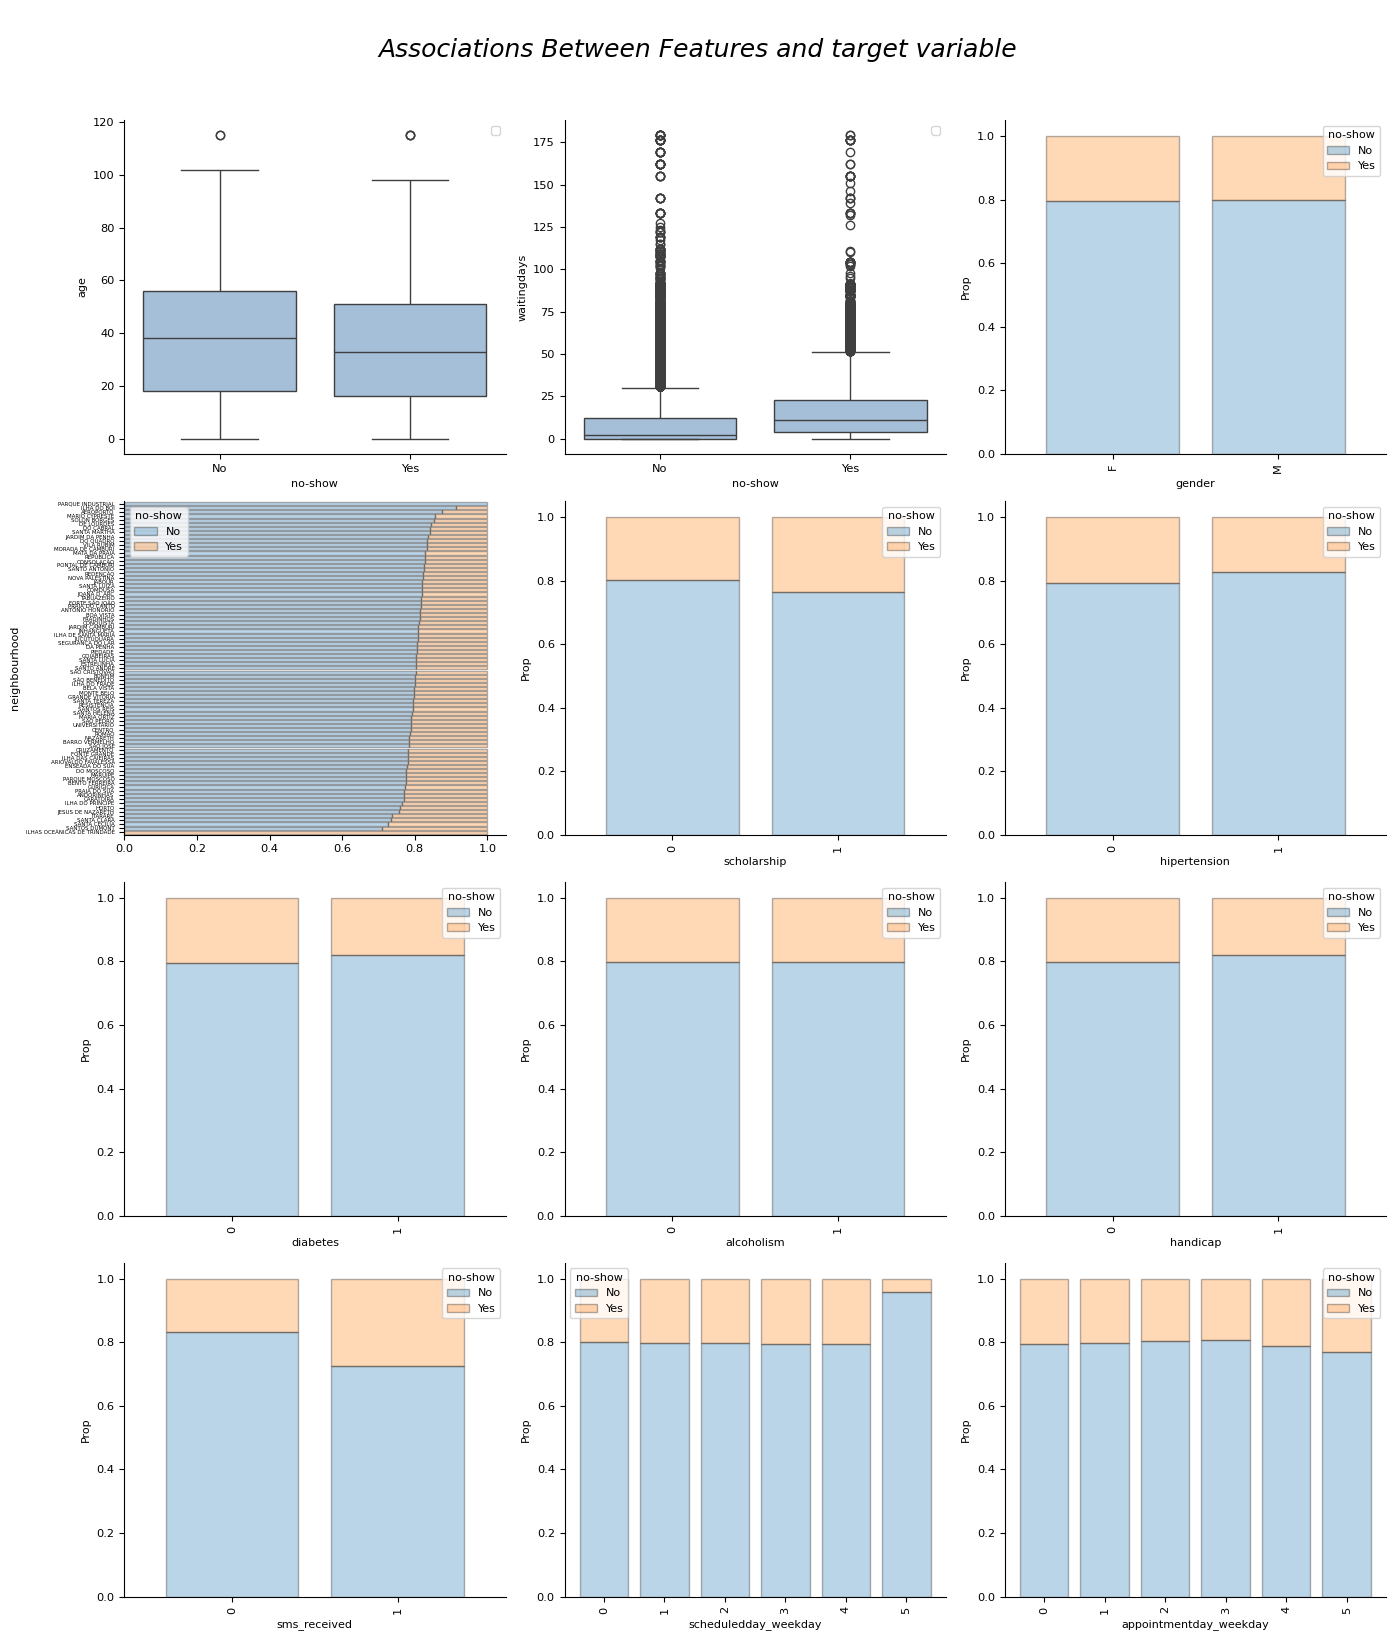

In [9]:
# 5.3.a Bivariate Function
def two_variate(df, cont_cols, cat_cols, target='no-show'):
    """Returns a grid of bivariate plot between features and target variable"""
    print('\n')
    counplot=1
    # Define a feature list
    cat_cols = [col for col in cat_cols if col != target]
    
    # Define number on rows columns for grid plot
    total_cols = len(cont_cols)+len(cat_cols)

    # Number of rows and columns for the grid
    nrows = int(np.ceil(total_cols / 3))
    ncols = min(total_cols, 3)

    # Figure for the grid plot
    plt.figure(figsize=[14, 4*nrows])

    # Loop through columns
    for column in cont_cols:
        # Define axes for grid plots
        ax = plt.subplot(nrows, ncols, counplot)

        # Use seaborn for boxplot
        sns.boxplot(x=df[target], y=df[column], boxprops={'facecolor': (0.3, 0.5, 0.7, 0.5)})
        ax.legend()

        # Increment the plot
        counplot+=1

    # Loop through catgorical columns and repeat the same thing
    for column in cat_cols:
        ax = plt.subplot(nrows, ncols, counplot)
        
        cros_prob = pd.crosstab(df[column], df[target], normalize='index')
        if column == 'neighbourhood':
            order = cros_prob['Yes'].sort_values(ascending=False).index
            
            cros_prob.loc[order].plot(kind='barh', label=column, 
                                      stacked=True, alpha=.3, width=.75, 
                                      edgecolor='k', ax=ax)
            # Adjust yticks size
            plt.yticks(fontsize=4)
        else:
            # Create a plot for the rest of features
            cros_prob.plot(kind='bar', stacked=True, width=.8,
                           ax=ax, alpha=.3, edgecolor='k')
            plt.ylabel('Prop')

        # Increment the plot
        counplot+=1

    # Add a title for the figure
    plt.suptitle('\nAssociations Between Features and target variable', style='italic', fontsize=18, y=1.02)
    plt.tight_layout()

    # Show the plots
    plt.show()

# Generate the grid plot
two_variate(df, cont_cols, cat_cols)

### 5.4 Statistical Tests:
    While bivariate plots are essential for building intuition, statistical tests are the "proof" that ensures our eyes aren't playing tricks on us.

#### 5.4.a Method 1: Two-sample t-test:
    This involves determining if the mean a continuous variable (output var) across the categories (independent var) are different. For each feature, we test:

*   $H\_0: µ\_1 = µ\_2$ ("Assumes there is no significant difference between the means.")
*   $H\_1: µ\_1 ≠ µ\_2$ ("Assumes there is significant difference between the means.")

In [10]:
# 5.4.b Let's flip age and output and no-show as input to compute t-test 
def ttest_score(df, column, target='no-show'):
    """Returns statistical test result of a given feature"""
    # Grouping base on category
    groups = [df.loc[df['no-show'] == i, column] for i in df['no-show'].unique()]

    # Compute stistical test
    statistic, p_val = stats.ttest_ind(*groups)
        
    return {
                'Features': column,
                'Statistic': statistic,
                'P-value': p_val,
                'Significant': 'Yes' if p_val < 0.05 else 'No'
               }

# Define an empty list
ttest_score_features = []

# Compute statistical test for all 
# continuous columns and append to the list
for column in cont_cols:
    ttest_score_features.append(ttest_score(df, column, target='no-show'))

# Convert result into a data frame
df_ttest = pd.DataFrame(ttest_score_features)

print('Two-sample Test Scores\n')
print(df_ttest.to_string(index=False)+'\n')

Two-sample Test Scores

   Features  Statistic  P-value Significant
        age      20.09     0.00         Yes
waitingdays     -63.05     0.00         Yes



#### 5.4.c Key Sights:
**Age and waitingdays VS no-show:** 
    
    With p-values less than 0.05, we reject the null hypothesis, indicating a significant mean difference between the groups. The age distribution shows that younger patients are more likely to miss their appointments than older patients, who are generally more susceptible to chronic diseases.

    Patients who had to wait longer are also more likely to miss their appointments. This may be due to factors such as distance or forgetfulness, as their appointments are scheduled far in advance. These features will be used in our predictive modeling.


#### 5.4.d Method 2: Chi-Square and Cramer's V for Categorical Variables

    The Cramer's V test measures the association strength between two categorical variables.

- **Range:** 0 (no association) to 1 (strong association)
- **Interpretation:**

     - **> 0.25:** Strong Association
  
     - **0.10 - 0.25:** Moderate Association
  
     - **< 0.10:** Weak Association
  
  Let's create a function to calculate these tests.

In [11]:
# 5.4.e Create a function that computes statistical tests for two categorical features

# Define a bin list and corresponding label
bins = [0, 12, 18, 44, 64, 115]

labels = ['Children', 'Adolescents', 'Young Adult', 'Middle-Aged', 'Senior']

# Create agegroup column
df['agegrp'] = pd.cut(df.age, bins=bins, labels=labels)

cat_cols.append('agegrp')

# Define the function to compute statistical test
def chi2_and_cramers_test(df, column, target='no-show'):
        """Retuns p and cramer's V values of a given column"""
        contingency = pd.crosstab(df[column], df[target])

        # Compute statostical test of contingency table
        chi2, p_val, dof, _ = stats.chi2_contingency(contingency)

        r, k = contingency.shape

        n = df.shape[0]

        pchi2 = chi2 / n

        pchi2corr = max(0, pchi2 - ((r-1)*(k-1)) / (n-1))
        rcorr = r - (r - 1)**2 / (n-1)
        kcorr = k - (k - 1)**2 / (n-1)
        v = np.sqrt(pchi2corr / min((kcorr-1), (rcorr-1)))

        # Retur v and p values
        return v, p_val

# Exlude target from categorical list
cat_cols = [x for x in cat_cols if x != 'no-show']

# Define an empty list for cramers and p values
cramers_v_test_score = []

# Compute p and cramers value for all variables
for column in cat_cols:
    v, p = chi2_and_cramers_test(df, column, target='no-show')

    if p < .05 and v > .25:
        strenght = 'Strong'
    elif p < .05 and v > .10:
        strenght = 'Moderate'
    elif p> .05 and v < 0.02:
        strenght = 'Negligible'
    else:
        strenght = 'Weak'

    cramers_v_test_score.append({'features': column,
                                 'p-value': p,
                                 'cramer v': v,
                                 'Strength': strenght})

df_cramers = pd.DataFrame(cramers_v_test_score).sort_values('cramer v', ascending=False)

# Display p-value and cramer results
print('\nCramers V test Scores:\n')
print(df_cramers.to_string(index=False))


Cramers V test Scores:

              features  p-value  cramer v   Strength
          sms_received     0.00      0.13   Moderate
                agegrp     0.00      0.08       Weak
         neighbourhood     0.00      0.06       Weak
          hipertension     0.00      0.04       Weak
           scholarship     0.00      0.03       Weak
              diabetes     0.00      0.01       Weak
appointmentday_weekday     0.00      0.01       Weak
              handicap     0.01      0.01       Weak
  scheduledday_weekday     0.11      0.01 Negligible
                gender     0.17      0.00 Negligible
            alcoholism     0.97      0.00 Negligible


#### 5.4.f Key Insights

* **Gender, alcoholism, and scheduledday_weekday** show no meaningful association with the target variable, indicating that they are unlikely to be strong predictors in our modeling.

* **Neighbourhood** exhibits substantial geographic variation. The boundary between “showed” and “no-showed” patients forms an “S”-shaped pattern, with rates ranging from nearly 100% (often based on a single observation) to as low as 10%.

* **Hypertension, handicap, scholarship, and diabetes** demonstrate minimal practical association with the target variable. Similarly, **scheduledday_hour** and **appointmentday_weekday** show only weak relationships.

* **sms_received** appears to be a strong predictor; however, its effect is likely confounded by lead time, as patients with longer waiting periods are more likely to receive SMS reminders.

### 6. Feature Interactions

We examine the interactions between **Gender vs Age** and **sms_received vs Age** in relation to appointment no-shows.

Feature interaction analysis helps visualize how the effect of one feature on the target variable depends on another feature. By combining at least two predictors along with the target variable, we can identify whether the relationship between a feature and the outcome changes across different levels of a second feature.


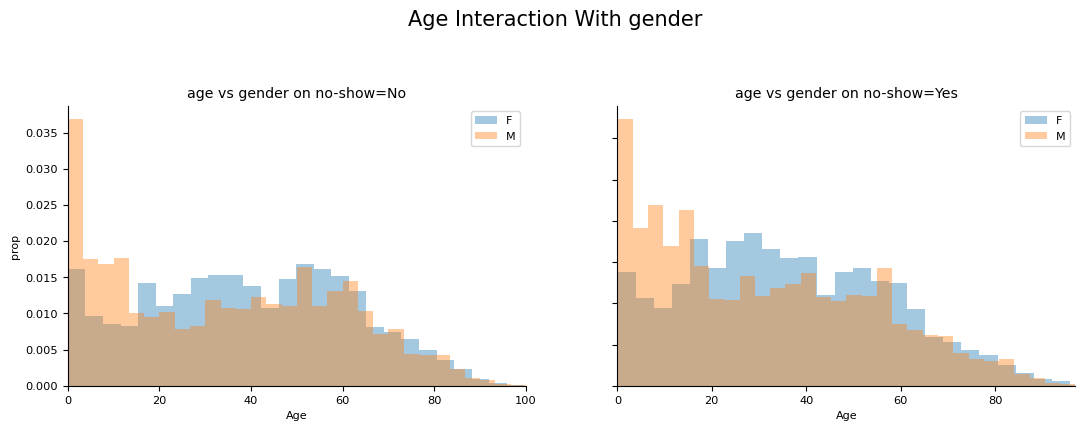

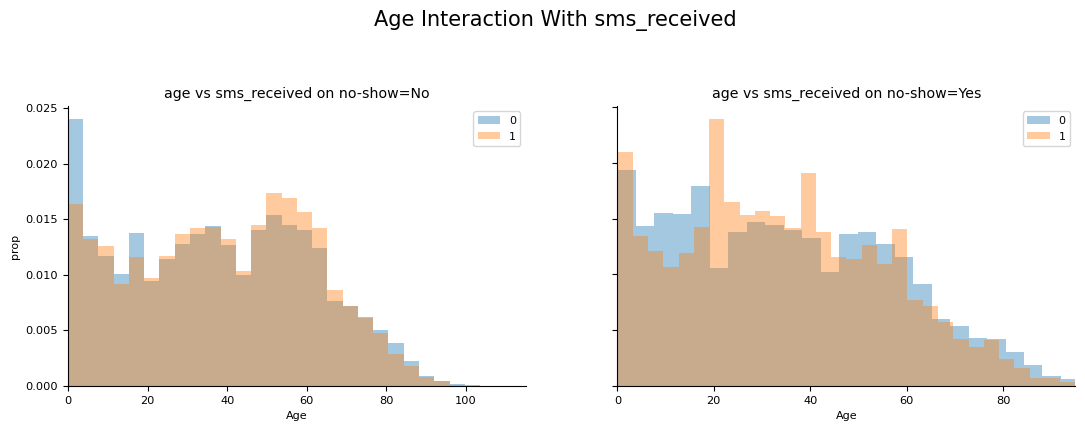

In [12]:
# 6.1 Define Age Interaction Function
def age_interaction_plot(df, col_cat, target='no-show'):
    """
    Plot the interaction between Age and a categorical feature across target classes.
    """
    # Create class series for plots
    countplot=1
    for status in df[target].unique():
        plt.subplot(2, 2, countplot)
        df_status = df.loc[df[target] == status]
        for cls in df_status[col_cat].unique():
            ages = df_status.loc[df_status[col_cat] == cls, 'age']

            ages.plot(kind='hist', label=cls, bins=30, sharey=True,
                      density=True, alpha=.4, figsize=[13, 8])

            # Adjust parameters
            plt.legend()
            plt.xlim([0,ages.max()])
            plt.xlabel('Age')
            plt.ylabel('prop')
            plt.title(f"age vs {col_cat} on no-show={status}")
        
        # Increment plot
        countplot+=1

    # Graph title
    plt.suptitle(f"Age Interaction With {col_cat}", fontsize=15, y=1)
    # Show plots
    plt.show()

# Generate the plot interactive plots
age_interaction_plot(df, 'gender')
age_interaction_plot(df, 'sms_received')

#### 6.1.a Gender Interaction (top two plots):
- **The "Spike" (Age 0-18):** Notice that in the No-show=Yes plot, the orange (Male) spike at age 0 is much higher than the blue (Female) spike.
- **The "Adult Hump" (Age 20-40):** In the No-show=Yes plot, the blue (Female) distribution is much "thicker" than the male one in the 20-40 age range.
- **The Discovery:** Male no-shows are heavily driven by children/teens. Female no-shows are driven more by young adults.
- **Why your p-value was 0.17:** Because the "extra" male children and "extra" female adults cancel each other out in the total count, making it look like gender doesn't matter. But these plots show that gender + age matters a lot!

#### 6.1.b SMS_received Interaction (bottom two plots:

   - **No-show=No (Left):** The blue (No SMS) is very high at age 0. This means infants who show up usually didn't get an SMS (likely last-minute checkups).
- **No-show=Yes (Right):** Look at the Orange (SMS Received) area between ages 20 and 60. It is much larger here than in the "No" plot.
- **The Discovery:** This confirms that for adults, receiving an SMS is strongly linked to missing the appointment. This isn't because the SMS is bad, but because those adults are the ones booking far in advance (the "high-risk" group).

    It shows the Outliers (The massive impact of infants/Age 0 on the entire dataset).

### 6.2 Heatmap Visualization 2: SMS vs Age Group Heatmap

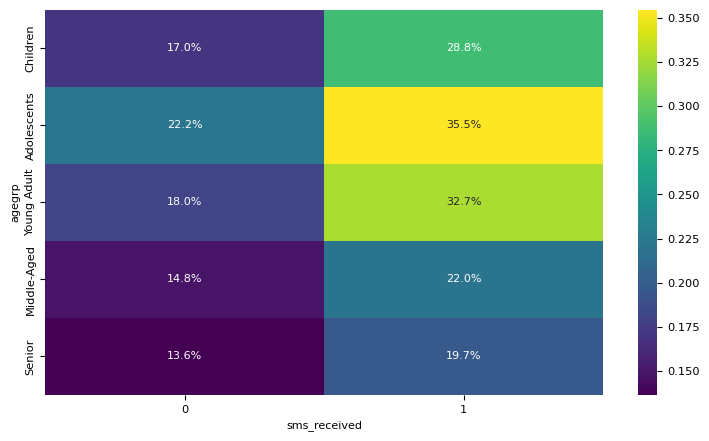

In [13]:
### 6.2.a Age Binning & Pivot table

# Define a bin list and corrsponding label
bins = [-np.inf, 12, 18, 44, 64, 115]
labels = ['Children', 'Adolescents', 'Young Adult', 'Middle-Aged', 'Senior']
df['agegrp'] = pd.cut(df.age, bins=bins, labels=labels)

# Define figure for plot
plt.figure(figsize=[9, 5])

# Convert target variable into a binary
df['no-show'] = np.where(df['no-show'] == 'No', 0, 1)

# Plot the pivot table
sns.heatmap(df.pivot_table(index='agegrp', columns='sms_received', values='no-show'), fmt='.1%', cmap='viridis', annot=True);

#### 6.2.b Key Insights:

    This heatmap reveals the "SMS Paradox" across different age groups. For every age category, patients who received SMS reminders (column 1) show higher no-show rates than those who didn't (column 0), confirming the lead-time confounding hypothesis.

### 8. Conclusions & Recommendations

#### **Summary of Findings:**

This analysis identified three tiers of features based on practical relevance:

**Tier 1: Key Drivers (Focus Here)**

        • SMS Reminders (Cramer's V = 0.1264): Strongest predictor, but confounded by lead time. Not ineffective; rather, sent to high-risk patients.

        • Scheduled Hour (Cramer's V = 0.0712): Afternoon appointments show slightly higher no-show rates.

        • Neighbourhood (Cramer's V = 0.0611): Geographic variation is significant and actionable.

**Tier 2: Weak but Significant Factors**

        • Age (Cramer's V = 0.0803 for age groups; Point-Biserial = -0.0603 for continuous): Statistically significant but minimal practical impact. Younger patients show slightly higher no-show rates, but the 3.5-year mean difference is negligible for prediction.

        • Health conditions (Hypertension, Diabetes, Scholarship) show statistical significance but minimal practical impact.

**Tier 3: Negligible Factors**

        • Gender, Alcoholism, and Disability status have no meaningful association with no-shows.

#### **Actionable Recommendations**

**1. Redesign SMS Strategy for Long Lead Times:**

        • Current SMS approach treats all patients equally. Instead, implement a tiered reminder system:

        • 0–7 days: Single SMS reminder (sufficient)

        • 8–30 days: SMS + email reminder

        • 30+ days: SMS + email + phone call (highest risk group)

        • Expected impact: Reduce no-show rate in 30+ day group from 41.6% to ~30%.

**2. Geographic Targeting:**

        • Identify high-risk neighbourhoods (>25% no-show rate) and implement localized interventions:

            • Partner with local community health workers

            • Improve transportation access

            • Offer flexible appointment times

        • Expected impact: 5–10% reduction in no-shows for targeted areas.

**3. Optimize Appointment Scheduling:**

        • Shift high-risk afternoon appointments (14:00–17:00) to morning slots when feasible.

        • For patients who must be scheduled in afternoons, apply Tier 2 reminder strategy (SMS + email).

        • Expected impact: 2–3% overall reduction in no-shows.

**4. Deprioritize Demographic Filters**

    While gender, age, and alcoholism show statistically significant associations with no-shows (p < 0.001), their effect sizes are negligible (Cramer's V < 0.10). This means:
    They're not useful for targeting — The predictive power is too weak
    They add noise to models — Including weak predictors can reduce model performance
    They're ethically problematic — Targeting based on demographics is discriminatory
    They waste resources — Better to focus on strong predictors like lead time

    Therefore, deprioritize them in favor of lead time, which has much stronger predictive power.

**Next I will perform a predictive modeling for Brazilian no-show apointment medical dataset**